# Assignment 1: Python & Image Basics, Edges and Corners

This assignment covers: environment setup, a tour of modern computer vision applications, pixel-level image operations, filtering, and edge/corner detection.

You will download and submit this Colab notebook (and a PDF report where indicated) to Gradescope. There are cells which require you to answer questions or complete and run code snippets.

The Colab notebook environment allows you to combine cells with python code and cells with text (markdown cells). Text cells can include "latex" mathematical formulas. Such formulas can be written in the inline mode, for example, $(x+y)^2=x^2+2xy+y^2$. Important or longer formulas may look better in a show mode, e.g. $$1=\sum_{n=1}^{\infty}\left(\frac{1}{2}\right)^n.$$
Latex is commonly used for scientific writing and you should use it for the written parts of your assignments. You should use text cells (markdown cells) to answer written questions or to present your explanations/comments in notebook reports with code. A list of common mathematical symbols in latex can be easily found online (e.g. https://oeis.org/wiki/List_of_LaTeX_mathematical_symbols). You can also find many online resources explaining latex for matematical equations, e.g. https://en.wikibooks.org/wiki/LaTeX/Advanced_Mathematics.

## Setup

#### 1. Colab tutorial


Google Colab (https://colab.research.google.com/) is an online platform for
editing, executing, and sharing Jupyter notebooks for Python hosted on Google drive. We will use Colab and Jupyter notebook for all the assignments in this course.

Tutorial URL: https://colab.research.google.com/notebooks/basic_features_overview.ipynb
Google sign-in is required to run any Colab notebook. For assignments you complete in this course, click "Copy to drive" so that you have a copy of the notebook in your Google Drive and changes will be saved as you work on the tutorial. Note that you do **not** need to submit the Colab tutorial or Python tutorial portions of this section.

#### 2. Python tutorial

Python tutorial
https://colab.research.google.com/github/data-psl/lectures2020/blob/master/notebooks/01_python_basics.ipynb
This tutorial introduces basic python programming, NumPy, and Matplotlib. This tutorial is intended to be review for students of this course.



### 3. Computer vision applications

You can run demos of state-of-the-art computer vision algorithms through https://huggingface.co, which is an online community for open-sourced models.

##### 1. Image classification
Image classification is the task of assigning a label or class to an entire image. For simplicity in this demo, each image is expected to have only one class. Image classification models take an image as input and return a prediction about which class the image belongs to.
URL: https://huggingface.co/tasks/image-classification.
Upload images of your choice and check which class has the highest probability.

##### 2. Text-to-image
Text-to-image is the task of generating an image based on a text description (prompt). Recent advances in deep learning has enabled image generation that is highly realistic.
URL: https://huggingface.co/tasks/text-to-image.
Try the online demo and generate desired images based on input text prompts. Change prompts and see how the generated images are changed accordingly.

##### 3. Visual question answering
Visual Question Answering is the task of answering open-ended questions based on an image. VQA models output natural language responses to natural language questions.
URL: https://huggingface.co/tasks/visual-question-answering.
Upload images of your choice and ask questions about uploaded images, e.g., ”what’s in this image", "how many people are there in this image”, etc.

##### 4. Image to text
Image to text models output text from a given image. Image captioning or optical character recognition are considered some of the most common applications of image to text.
URL: https://huggingface.co/tasks/image-to-text.
Upload images of your choice and see what descriptions are generated.

##### 5. Object detection
Object detection models allow users to identify objects of certain defined classes. Object detection models receive an image as input and output the images with bounding boxes and labels on detected objects.
URL: https://huggingface.co/tasks/object-detection.
Upload images of your choice for the demo. Each bounding box is associated with a probability. Hover over each bounding box to see the output probability.

# Problem 1: Finding Shortcomings of Vision Models

So, are all of the tasks of computer vision solved? No, not at all - new research tasks pop up all the time, and even the tasks we observed in this section are not completely solved! Based on images you selected in these demo systems, identify two shortcomings of any of the above models. If you selected "easy" images, you may need to try some additional images to stump the model. For each of the two shortcomings, display in this notebook the image you provided to the system, and explain what the model got wrong when evaluating the image.

In [ ]:
# Insert your two shortcoming images and explanations in this cell.
# For each image: display it (e.g., using matplotlib.pyplot.imshow) and,
# below or alongside it, explain what the model got wrong when evaluating it.
#
# Image 1:


# Explanation 1:


# Image 2:


# Explanation 2:

Besides using the online demo webpages, we can also access these models programmatically through the HuggingFace API. This may be helpful in some of the last open-ended lab assignments.

First, we must install some pacakges using the code block below.

We provide these lines to install packages required to use the inference API.


In [ ]:
! pip install transformers
! pip install diffusers

You can download an image of your choosing for working with these tools. Try out each task model, following the tutorials in the samples below.

1. Image classification

See code sample in the URL below. Use transformers.pipeline instead of huggingface.js. URL: https://huggingface.co/tasks/image-classification

2. Visual question answering

See code sample in the URL https://huggingface.co/tasks/visual-question-answering

3. Image to text

See code sample in the URL https://huggingface.co/tasks/image-to-text

4.  Object detection

See code sample in the URL https://huggingface.co/tasks/object-detection

5. Text to image

See code sample in the URL https://huggingface.co/tasks/text-to-image


In [ ]:
# Practice using the HuggingFace inference API in this cell.
# Follow the tutorials linked above and try each of the five tasks
# (image classification, VQA, image-to-text, object detection, text-to-image)
# on an image of your choosing.

Now that we've seen some impressive and inspiring applications of computer vision, and equipped ourselves with the tools to use some of these models in our future projects out-of-the-box, it's time to go all the way back to the beginning, and start learning how these methods and tools came to be.



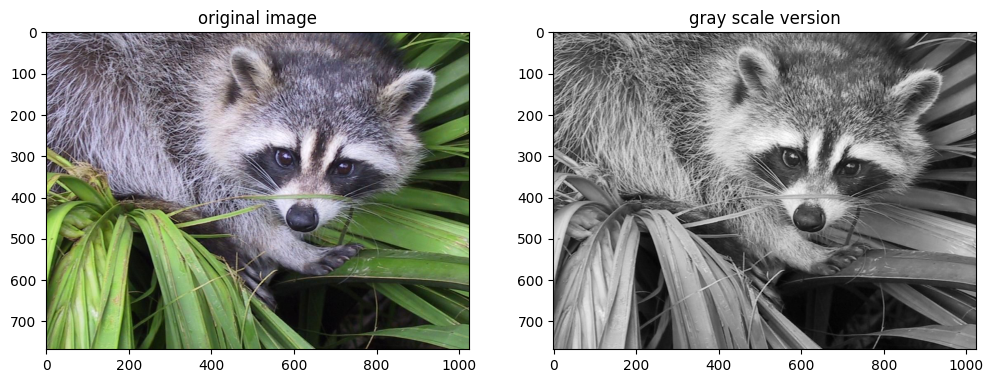

In [ ]:
# This cell loads some libraries and a test image you can use. Feel free to load your own images
# but you must save them in an "images" subdirectory before creating .zip for your submission.

%matplotlib inline
# NOTE: all "magic" options for backend plotting are: inline, notebook, and "external" (default)
# see  http://ipython.readthedocs.io/en/stable/interactive/plotting.html for details
import numpy as np
import matplotlib
import matplotlib.image as image
import matplotlib.pyplot as plt
from scipy import misc
import scipy
from skimage.color import rgb2gray

im = scipy.datasets.face()     # a sample image in misc library
#im=image.imread("../images/IMG_3306.jpg") # another image (loaded from your file), uncomment one

plt.figure(1,figsize = (12, 8))
plt.subplot(121)
plt.imshow(im)
plt.title("original image")
plt.subplot(122)
plt.imshow(rgb2gray(im),cmap="gray")
plt.title("gray scale version")
plt.show()

# Problem 2: NumPy Basics

Complete each of the following exercises using NumPy operations to generate the desired output. You may find this guide to NumPy to be helpful: https://numpy.org/doc/2.2/user/absolute_beginners.html

![Image Description](https://drive.google.com/uc?export=view&id=1sbCuFt4_Kypjl3Hk_PfnAM_1ytAdDu5b)

(a) Point-wise multiply A with B and set it to C.

(b) Calculate the inner product of the 2nd and 3rd row of C.

(c) Find the minimum and maximum values and their corresponding row and column indices in matrix C. If there are multiple min/max values, you must list all their indices.

In [ ]:
# Your code here

# Problem 3: Getting and Setting Pixels


The most basic operation we want to do is change the pixels in an image. As we talked about in class, we represent an image as a 3 dimensional tensor. We have spatial information as well as multiple channels which combine together to form a color image. The convention is that the coordinate system starts at the top left of the image.

Your first task is to write two functions:

    def get_pixel(image, x, y, c)
    def set_pixel(image, x, y, c, v)

`get_pixel` should return the pixel value at column `x`, row `y`, and channel `c`. `set_pixel` should set channel `c` of the pixel `(x,y)` to the value `v`. You will need to do bounds checking to make sure the coordinates are valid for the image. `set_pixel` should simply return without doing anything if you pass in invalid coordinates.

We can test out our pixel-setting code on `pav.png`; try removing all of the red channel by setting red values to 0. Display the resulting image next to the original in your report.

In [ ]:
# Your code here

# Problem 4: Image Transform: From Color to Gray

#####  Use the following cells to write your own python functions that take an arbitrary RGB image and outputs its grayscale version. The functions' input should be an RGB image. The computed grayscale image should be a 2D array of the same size as the input image. You should write your own code for converting colored images to grayscale images without using any standard functions like $rgb2gray$ from "skimage" in the cell above, or any other image library for python.  Treat greyscale value as a direct $average$ of the corresponding R G and B values. You should write three versions A, B, and C, as detailed in each cell below. In addition to completing the functions, answer the question (a) below.

In [ ]:
# Solution A: (for-loops)
# In this version you should explicitly use two nested for-loops traversing individual pixels
# of the input image, computing the average of R, G, and B values for each pixel, and copying them
# to the corresponding element of the output matrix (gray-scale image).
def toGrayScale_A(color_image):
    return


In [ ]:
# Solution B: (basic numpy operators for matrix operations)
# In the next two versions you can't use for-loops (or other loops) explicitly traversing pixels.
# In B below you should first separate image colors into individual 2D arrays (matrices) R,G and B
# using "slicing" or "reshaping" and then compute the average of these matrices 0.3333*(A+B+C) directly
# using numpy operators + and * for adding and scaling matrices.
# HINT: your code may look like a linear algebraic expresion.
def toGrayScale_B(color_image):
    return


In [ ]:
# Solution C: (vectorized functions)
# In this version you should use numpy function 'dot' applying it
# directly to the colored image (3d array) and vector [0.33,0.33,0.33] defining weights
# for each color component.
def toGrayScale_C(color_image):
    return


In [ ]:
%%time
# Test your code for version A in this cell.
plt.figure(2,figsize = (12, 8))
plt.subplot(121)
plt.imshow(im)
plt.title("original image")
plt.subplot(122)
plt.imshow(toGrayScale_A(im),cmap="gray")
plt.title("grayscale version")
plt.show()

In [ ]:
%%time
# Test your code for version B in this cell.
plt.figure(3,figsize = (12, 8))
plt.subplot(121)
plt.imshow(im)
plt.title("original image")
plt.subplot(122)
plt.imshow(toGrayScale_B(im),cmap="gray")
plt.title("grayscale version")
plt.show()

In [ ]:
%%time
plt.figure(4,figsize = (12, 8))
plt.subplot(121)
plt.imshow(im)
plt.title("original image")
plt.subplot(122)
plt.imshow(toGrayScale_C(im),cmap="gray")
plt.title("grayscale version")
plt.show()

(a) What perceptual issues arise when using a "simple average" formula to compute a grayscale image?

Note: this problem should teach you to avoid using for-loops (or other explicit loops) when coding operations over image pixels or, more generally, matrix elements! Compare the running times reported in the last three cells and decide for yourself what would happen if the image was much larger and you had to run your code on many images. Numpy was designed to avoid that type of code. You should always use basic 'numpy' operators for matrices that make your code both efficient and simple. In many cases, numpy's code should look exactly like linear algebraic equations. When basic linear algebraic operators are not enough, you should look for appropriate "vectorized" functions (e.g. like 'dot'). Learning how to use vectorized functions is significant for proper numpy coding. You should also get comfortable with "slicing" and "reshaping" operations as soon as possible - they are ubiquitous in numpy and critical for effective code.

# Problem 5: Pixel Arithmetic and Thresholding

Write two functions:
- Your first function should add 15 to each value of the input image. Set all pixel values greater than 255 to 255.
- Your second function should calculate the median of all values in the image. Then, threshold the input image by the median value you calculated (i.e., set all values greater than the median to 0, and all values less than or equal to the median to 1). This is an example of a binary image.

Display the output of each of your functions next to a copy of the original image.

In [ ]:
# Your code here

# Problem 6: Pixel Shuffling

##### Write code that randomly shuffles all grayscale image pixels using function numpy.random.shuffle. Show the original image and two shuffled results. Display the histograms of both the original and the "shuffled" images. Add a markdown cell describing what you notice about the histograms.

In [ ]:
# Solution: write your code in this cell. Show one image and the results of shuffling.

*What do you notice about the histograms of the original and shuffled images? (write your answer here)*

# Problem 7: Chroma Keying – Turning UC Merced into UC Flavortown

Chroma keying is used for extracting the foreground from images, with the background typically being a green screen. In this problem, you have been provided 2 images: `guy.png` and `uc_flavortown.jpg`. Write a script to extract the foreground from `guy.png` and overlay the foreground on `uc_flavortown.jpg`. In your report you should include:

- A binary image showing the foreground mask, i.e., all foreground pixels set to 1 (or 255, or 255, 255, 255) and all background pixels set to 0. Your choice of 1 or 255 or a triplet of 255s will depend on how you choose to represent and render your binary image.
- An image with the background pixels set to 0 and the foreground pixels set to their original values.
- An image with the foreground overlayed on `uc_flavortown.jpg`. Note that depending on how you implement your algorithm, you may need to resize one of the images to match the dimensions of the other.

*Hint: we know how to get and set pixels now. Which pixels do we want to filter? Which channel might we be examining in our function? You may find it helpful to use a "color picker" tool from applications like MS Paint or Google Slides to identify the color of certain regions of the image to perform thresholding -- not all greens have the same value(s)!*


In [ ]:
# Your code here

# Problem 8: Noise Cleaning

Load the images br, noisy1, and noisy2. For each filtering step, include the resulting filtered images, and answer the questions in a markdown cell underneath.

- Which image has Gaussian noise, and which image has Salt \& Pepper noise?
- Use a 1x3 horizontal median filter to clean both images. What are the resulting mean squared errors (MSEs) when comparing the filtered images to the original?
- Use a 3x3 median filter to clean both images. What are the resulting MSEs?
- Use a 3x3 mean filter to clean both images. What are the resulting MSEs?
- Discuss your results; which filter(s) worked best for which images, and why?


In [ ]:
# Your code here

*Answer the Problem 8 questions here:*

- Which image has Gaussian noise, and which has Salt & Pepper?
- MSEs for the 1x3 horizontal median filter:
- MSEs for the 3x3 median filter:
- MSEs for the 3x3 mean filter:
- Which filter(s) worked best for which image, and why?

# Problem 9: Median Filtering

##### Prove that median filtering in not a linear image transormation. HINT: find a counter example showing that for some vectors of the same dimensions $A$ and $B$, $$Med(A + B)\neq Med(A) + Med(B)$$  where operation $Med(X)$ returns median of the elements of vector $X$.

Solution: (write your solution in this cell)

# Problem 10: Image Differentiation and Noise

##### (a) Image differentiation: Write your own code for a python function estimating partial derivatives $d(x,y):=\frac{\partial}{\partial x} f(x,y)$ of any greyscale image $f$ with respect to variable $x$. The function should return a real-valued matrix of the same size as the input image $f$. Use the "backward" difference approximation $$\frac{\partial}{\partial x} f(x,y)\approx \frac{f(x,y)-f(x-\Delta,y)}{\Delta}$$ where $\Delta$ is the distance between pixels (you  can assume  $\Delta=1$). As mentioned earlier, your numpy code should not use (double) for-loops for traversing the elements of matrices. This is highly inefficient. You should learn to use appropriate numpy functions that avoid this. For example, for this excercise you can use numpy.roll to compute image with pixels shifted to the left or right and use linear operations over images as matrices (pointwise addition/subtraction).

In [ ]:
# Solution: write your code in this cell


##### (b): Apply your code in (a) to some grey-scale image $f$. Display the following images: the original image $f$ and its derivative $g=\frac{\partial}{\partial x} f$ (real-valued). Your matplotlib plots for $f$ and $g$ should include the "color bar" clearly indicating the corresponding ranges.
Note: to display real-valued matrix with negative and positive values as some image, matplotlib can use some (typically linear) range transformation or point processing that maps the whole range of the matrix values onto an interval of grey-scale intensities, e.g. [0,255]. The color bar can illustrate such transformation showing which real-values in the matrix range correspond to different grey-levels in the displayed image. You can expect that for the matrix of derivatives $g$ the medium grey-level (125) would correspond to zero derivatives, while the negative derivatives are displayed by darker intensities [0,125], and positive derivatives are displayed by brighter intensities [125,255].

Besides greyscale [0,255], matplotlib can map the range of a matrix values onto some colors intervals (from red to blue or from brown to yellow), thus the name "color bar". It can also use some non-linear (e.g. logarithmic) range maps that maybe useful for visualizing certain real-valued matrices, e.g. with many extremely small (or large) positive values.

In [ ]:
# Solution: write your code in this cell


# Problem 11: Harris Corners

##### (a) In this problem we use $\nabla I (x,y)$ to denote a gradient of image intensities at point $(x,y)$ only to emphasize this dependence of the gradient on location. Assume that $\nabla I (x,y)$  is a non-zero vector at a given point $(x,y)$. What is the rank of matrix $\nabla I(x,y) \cdot \nabla I^T(x,y)$ and why?

Solution:

##### (b) Assume that an image patch (window $w$) contains a straight intensity edge. What should be the rank of Harris matrix  at that patch/window $M_w = \sum_{(x,y)\in w} \nabla I(x,y) \cdot \nabla I^T(x,y)$ and why?

Solution:

##### (c) What is the rank of Harris matrix for window $W_c$ containing a corner at an intersection of two straight edges? Provide a formal proof. HINT: You can assume that pixels in $W_c$ have either a zero-gradient, or one of two distint gradient vectors corresponding to two straight edges.

Solution:  

# Problem 12: Canny Edge Detection

In this problem, you are required to write a function that performs Canny Edge Detection. The function has the following specifications:

- It takes in two inputs: a grayscale image, and a threshold $t_e$.
- It returns the edge image.

A brief description of the algorithm is given below. Make sure your function reproduces the each step as given.

- Smoothing: It is inevitable that all images taken from a camera will contain some amount of noise. To prevent noise from being mistaken for edges, noise must be reduced. Therefore the image is first smoothed by applying a Gaussian filter. A Gaussian kernel with standard deviation $\sigma = 1.4$ (shown below) is to be used.

$$k = \frac{1}{159} \cdot \begin{bmatrix}
2 & 4 & 5 & 4 & 2\\
4 & 9 & 12 & 9 & 4\\
5 & 12 & 15 & 12 & 5\\
4 & 9 & 12 & 9 & 4\\
2 & 4 & 5 & 4 & 2
\end{bmatrix}
$$

- Finding Gradients: The next step is to find the horizontal and vertical gradients of the smoothed image using the Sobel operators. The gradient images in the x and y-direction, $G_x$ and $G_y$ are found by applying the kernels $k_x$ and $k_y$ given below:

$$k_x = \begin{bmatrix}
-1 & 0 & 1\\
-2 & 0 & 2\\
-1 & 0 & 1
\end{bmatrix},
k_y = \begin{bmatrix}
-1 & -2 & -1\\
0 & 0 & 0\\
1 & 2 & 1
\end{bmatrix}.
$$

The corresponding gradient magnitude image is computed using:

$$|G| = \sqrt{G_x^2 + G_y^2},$$

and the edge direction image is calculated as follows:

$$G_{\theta} = arctan(\frac{G_y}{G_x}).$$

- Non-maximum Suppression (NMS): The purpose of this step is to convert the thick edges in the gradient magnitude image to "sharp" edges. This is done by preserving all local maxima in the gradient image, and deleting everything else. This is carried out by recursively performing the following steps for each pixel in the gradient image:

- Round the gradient direction $\theta$ to nearest 45 degrees, corresponding to the use of an 8-connected neighbourhood.

- Compare the edge strength of the current pixel with the edge strength of the pixel in the positive and negative gradient direction i.e. if the gradient direction is north ($\theta = 90$ degrees), then compare with the pixels to the north and south.

- If the edge strength of the current pixel is largest; preserve the value of the edge strength. If not, suppress (remove) the value.

- Thresholding: The edge-pixels remaining after the NMS step are (still) marked with their strength. Many of these will probably be true edges in the image, but some may be caused by noise or color variations. The simplest way to remove these would be to use a threshold, so that only edges stronger than a certain value would be preserved. Use the input $t_e$ to perform thresholding on the non-maximum suppressed magnitude image.

- Evaluate your canny edge detection function on b.jpg for a suitable value of $t_e$ that retains the structural edges, and removes the noisy ones. What threshold did you choose?

In [ ]:
# Your code here

*What threshold $t_e$ did you choose, and why? (write your answer here)*

Congratulations on completing Assignment 1! Please turn in your PDF report and .ipynb to Gradescope.